# **Laboratorio 6 - Intervalos de Confianza**
# **Estadistica Inferencial**
## **Maria Monica Ahumada Lora**
> Email: ahumadamary30@gmail.com/maaahumada@utb.edu.co

> Celular: 3052413815

> Código Estudiantil: T00071071

# **https://rpubs.com/mgsaavedraro/1236893**

## **Taller: Intervalos de Confianza para la Media en R**

Objetivos

+ Comprender qué es un intervalo de confianza y su interpretación.
+ Calcular intervalos de confianza para la media con varianza conocida y desconocida.
+ Calcular intervalos de confianza para diferentes niveles de confianza.


Ejercicio 1: Intervalo de Confianza para la Media (Varianza Conocida)
Cuando la varianza de la población es conocida, usamos la distribución normal para calcular el intervalo de confianza.

Datos: Supón que tienes una muestra de 30 estudiantes con puntuaciones en un examen, y conoces la desviación estándar de la población que es 15. Calcula el intervalo de confianza del 95% para la media de la muestra.

# **Librerias para Trabar en R**

In [2]:
# @title **Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


<a name="inicio"></a>


## **1.** [Problema 1.](#T1)
## **2.** [Grafico ejercicio 1.](#T2)

## **3.** [Grafico ejercicio 1 con python.](#T3)

## **4.** [Problema 2.](#T4)

## **5.** [Grafico ejercicio 2.](#T5)

## **6.** [Grafico ejercicio 2 con python.](#T6)

## **7.** [Problema 3.](#T7)


## **8.** [Grafico ejercicio 3.](#T8)

## **9.** [Grafico ejercicio 3 con python.](#T9)


## **10.** [Problema 4](#T10)

## **11.** [Grafico ejercicio 4.](#T11)

## **12.** [Grafico ejercicio 4 con python.](#T12)

## **13.** [](#T13)

## **14.** [](#T14)

## **15.** [](#T15)

## **16.** [](#T16)

## **17.** [](#T17)


## **18.** [](#T18)

## **19.** [](#T19)


## **20.** [](#T20)

## **21.** [](#T21)

## **22.** [](#T22)

## **23.** [](#T23)

## **24.** [](#T24)

## **25.** [](#T25)

## **26.** [](#T26)

## **27.** [](#T27)


## **28.** [](#T28)

## **29.** [](#T29)


## **30.** [](#T30)

## **31.** [](#T31)



[ULTIMO](#ULTIMO)

[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
#  Problema 1.
Datos: Supón que tienes una muestra de 30 estudiantes con puntuaciones en un examen, y conoces la desviación estándar de la población que es 15. Calcula el intervalo de confianza del 95% para la media de la muestra, conociendo que la muestra tiene una media de 75.


In [3]:
# @title **Parámetros conocidos**
%%R
media_muestra <- 75  # Media de la muestra
sigma <- 15          # Desviación estándar de la población
n <- 30              # Tamaño de la muestra
nivel_confianza <- 0.95

# Cálculo del error estándar
error_estandar <- sigma / sqrt(n)

# Valor z crítico
z_critico <- qnorm(1 - (1 - nivel_confianza) / 2)

# Intervalo de confianza
limite_inferior <- media_muestra - z_critico * error_estandar
limite_superior <- media_muestra + z_critico * error_estandar

cat("El intervalo de confianza del 95% para la media es: [", limite_inferior, ",", limite_superior, "]\n")

El intervalo de confianza del 95% para la media es: [ 69.63242 , 80.36758 ]


[⬆️ Volver al inicio](#inicio)

<a name="T2"></a>
## Grafico ejercicio 1.


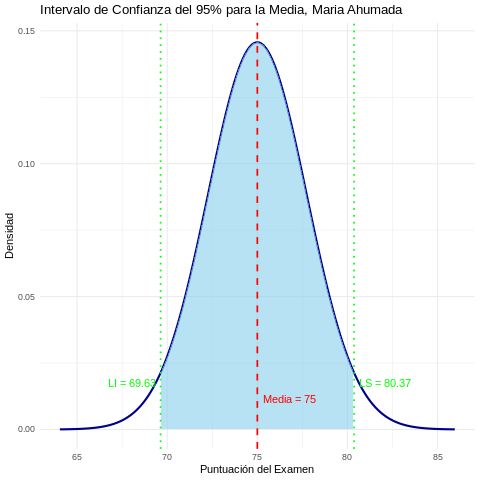

In [5]:
%%R
# Asegúrate de que ggplot2 esté instalado y cargado
if (!requireNamespace("ggplot2", quietly = TRUE)) {
  install.packages("ggplot2")
}
library(ggplot2)

# Definir los parámetros de la distribución normal
media_muestra <- 75  # Media de la muestra
sigma <- 15          # Desviación estándar de la población
n <- 30              # Tamaño de la muestra
nivel_confianza <- 0.95

error_estandar <- sigma / sqrt(n)
z_critico <- qnorm(1 - (1 - nivel_confianza) / 2)

limite_inferior <- media_muestra - z_critico * error_estandar
limite_superior <- media_muestra + z_critico * error_estandar

# Crear un rango de valores para la distribución normal
x_vals <- seq(media_muestra - 4 * error_estandar, media_muestra + 4 * error_estandar, length.out = 500)
y_vals <- dnorm(x_vals, mean = media_muestra, sd = error_estandar)

# Crear un dataframe para ggplot
df_plot <- data.frame(x = x_vals, y = y_vals)

# Crear el gráfico
ggplot(df_plot, aes(x = x, y = y)) +
  geom_line(color = "darkblue", size = 1) +
  geom_ribbon(data = subset(df_plot, x >= limite_inferior & x <= limite_superior),
              aes(ymin = 0, ymax = y), fill = "skyblue", alpha = 0.6) +
  geom_vline(xintercept = media_muestra, linetype = "dashed", color = "red", size = 0.8) +
  geom_vline(xintercept = limite_inferior, linetype = "dotted", color = "green", size = 0.8) +
  geom_vline(xintercept = limite_superior, linetype = "dotted", color = "green", size = 0.8) +
  labs(title = "Intervalo de Confianza del 95% para la Media, Maria Ahumada",
       x = "Puntuación del Examen",
       y = "Densidad") +
  annotate("text", x = limite_inferior, y = max(y_vals) * 0.1, label = paste0("LI = ", round(limite_inferior, 2)), hjust = 1.1, vjust = -0.5, color = "green") +
  annotate("text", x = limite_superior, y = max(y_vals) * 0.1, label = paste0("LS = ", round(limite_superior, 2)), hjust = -0.1, vjust = -0.5, color = "green") +
  annotate("text", x = media_muestra, y = max(y_vals) * 0.1, label = paste0("Media = ", round(media_muestra, 2)), hjust = -0.1, vjust = 1.5, color = "red") +
  theme_minimal()


[⬆️ Volver al inicio](#inicio)

<a name="T3"></a>
## Grafico ejercicio 1 con python.


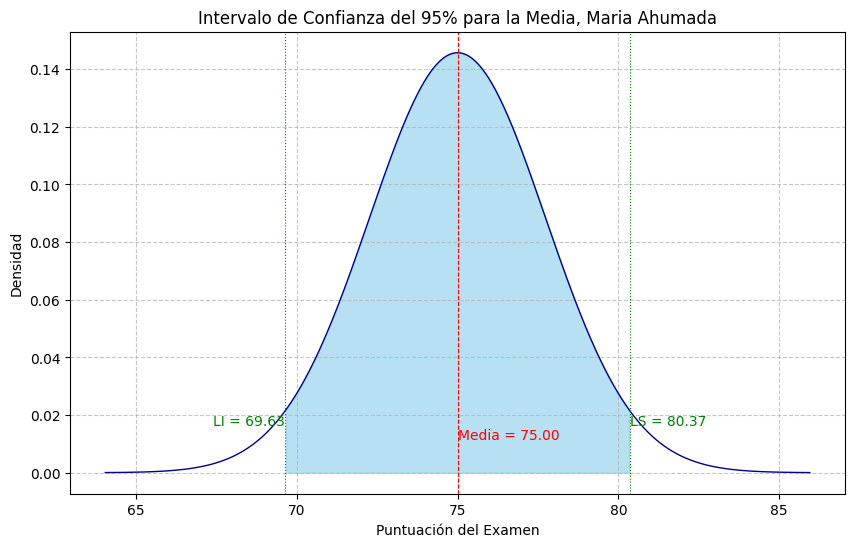

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Definir los parámetros de la distribución normal
media_muestra = 75  # Media de la muestra
sigma = 15          # Desviación estándar de la población
n = 30              # Tamaño de la muestra
nivel_confianza = 0.95

# Cálculo del error estándar
error_estandar = sigma / np.sqrt(n)

# Valor z crítico
z_critico = norm.ppf(1 - (1 - nivel_confianza) / 2)

# Intervalo de confianza
limite_inferior = media_muestra - z_critico * error_estandar
limite_superior = media_muestra + z_critico * error_estandar

# Crear un rango de valores para la distribución normal
x_vals = np.linspace(media_muestra - 4 * error_estandar, media_muestra + 4 * error_estandar, 500)
y_vals = norm.pdf(x_vals, loc=media_muestra, scale=error_estandar)

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, color='darkblue', linewidth=1)

# Sombrear el intervalo de confianza
x_fill = x_vals[(x_vals >= limite_inferior) & (x_vals <= limite_superior)]
y_fill = y_vals[(x_vals >= limite_inferior) & (x_vals <= limite_superior)]
plt.fill_between(x_fill, 0, y_fill, color='skyblue', alpha=0.6)

# Líneas verticales
plt.axvline(media_muestra, color='red', linestyle='dashed', linewidth=0.8, label=f'Media = {media_muestra:.2f}')
plt.axvline(limite_inferior, color='green', linestyle='dotted', linewidth=0.8, label=f'LI = {limite_inferior:.2f}')
plt.axvline(limite_superior, color='green', linestyle='dotted', linewidth=0.8, label=f'LS = {limite_superior:.2f}')

# Etiquetas y título
plt.title('Intervalo de Confianza del 95% para la Media, Maria Ahumada')
plt.xlabel('Puntuación del Examen')
plt.ylabel('Densidad')

# Anotaciones de texto
plt.text(limite_inferior, plt.gca().get_ylim()[1] * 0.1, f'LI = {limite_inferior:.2f}', horizontalalignment='right', verticalalignment='bottom', color='green')
plt.text(limite_superior, plt.gca().get_ylim()[1] * 0.1, f'LS = {limite_superior:.2f}', horizontalalignment='left', verticalalignment='bottom', color='green')
plt.text(media_muestra, plt.gca().get_ylim()[1] * 0.1, f'Media = {media_muestra:.2f}', horizontalalignment='left', verticalalignment='top', color='red')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


[⬆️ Volver al inicio](#inicio)

<a name="T4"></a>
## Problema 2: Intervalo de Confianza para la Media (Varianza Desconocida)
Si la varianza de la población es desconocida, usamos la distribución t de Student en lugar de la normal.

Datos: Una muestra de 20 estudiantes tiene una media de 70 y una desviación estándar de 10. Calcula el intervalo de confianza del 95% para la media.


In [10]:
# Parámetros desconocidos
%%R
media_muestra <- 70     # Media de la muestra
s <- 10                 # Desviación estándar de la muestra
n <- 20                 # Tamaño de la muestra
nivel_confianza <- 0.95

# Cálculo del error estándar
error_estandar <- s / sqrt(n)

# Valor t crítico
t_critico <- qt(1 - (1 - nivel_confianza) / 2, df = n - 1)

# Intervalo de confianza
limite_inferior <- media_muestra - t_critico * error_estandar
limite_superior <- media_muestra + t_critico * error_estandar

cat("El intervalo de confianza del 95% para la media es: [", limite_inferior, ",", limite_superior, "]\n")

El intervalo de confianza del 95% para la media es: [ 65.31986 , 74.68014 ]


[⬆️ Volver al inicio](#inicio)

<a name="T51"></a>
## Grafico ejercicio 2.




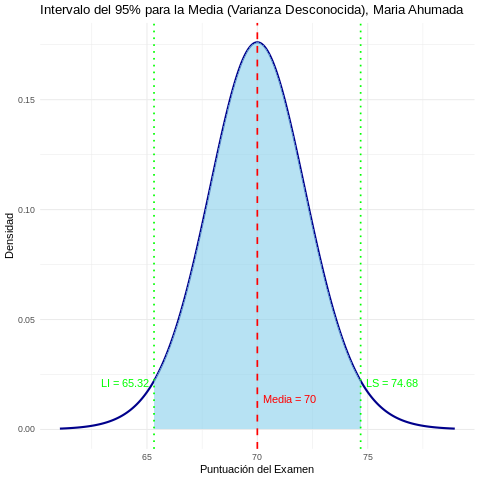

In [14]:
%%R
# Asegúrate de que ggplot2 esté instalado y cargado
if (!requireNamespace("ggplot2", quietly = TRUE)) {
  install.packages("ggplot2")
}
library(ggplot2)

# Parámetros del Problema 2 (Varianza Desconocida)
media_muestra_p2 <- 70     # Media de la muestra
s_p2 <- 10                 # Desviación estándar de la muestra
n_p2 <- 20                 # Tamaño de la muestra
nivel_confianza_p2 <- 0.95

# Cálculo del error estándar
error_estandar_p2 <- s_p2 / sqrt(n_p2)

# Valor t crítico
t_critico_p2 <- qt(1 - (1 - nivel_confianza_p2) / 2, df = n_p2 - 1)

# Intervalo de confianza
limite_inferior_p2 <- media_muestra_p2 - t_critico_p2 * error_estandar_p2
limite_superior_p2 <- media_muestra_p2 + t_critico_p2 * error_estandar_p2

# Crear un rango de valores para la distribución t de Student
# Usamos los grados de libertad (n-1)
x_vals_p2 <- seq(media_muestra_p2 - 4 * error_estandar_p2, media_muestra_p2 + 4 * error_estandar_p2, length.out = 500)
y_vals_p2 <- dt((x_vals_p2 - media_muestra_p2) / error_estandar_p2, df = n_p2 - 1) / error_estandar_p2

# Crear un dataframe para ggplot
df_plot_p2 <- data.frame(x = x_vals_p2, y = y_vals_p2)

# Crear el gráfico
ggplot(df_plot_p2, aes(x = x, y = y)) +
  geom_line(color = "darkblue", size = 1) +
  geom_ribbon(data = subset(df_plot_p2, x >= limite_inferior_p2 & x <= limite_superior_p2),
              aes(ymin = 0, ymax = y), fill = "skyblue", alpha = 0.6) +
  geom_vline(xintercept = media_muestra_p2, linetype = "dashed", color = "red", size = 0.8) +
  geom_vline(xintercept = limite_inferior_p2, linetype = "dotted", color = "green", size = 0.8) +
  geom_vline(xintercept = limite_superior_p2, linetype = "dotted", color = "green", size = 0.8) +
  labs(title = "Intervalo del 95% para la Media (Varianza Desconocida), Maria Ahumada",
       x = "Puntuación del Examen",
       y = "Densidad") +
  annotate("text", x = limite_inferior_p2, y = max(y_vals_p2) * 0.1, label = paste0("LI = ", round(limite_inferior_p2, 2)), hjust = 1.1, vjust = -0.5, color = "green") +
  annotate("text", x = limite_superior_p2, y = max(y_vals_p2) * 0.1, label = paste0("LS = ", round(limite_superior_p2, 2)), hjust = -0.1, vjust = -0.5, color = "green") +
  annotate("text", x = media_muestra_p2, y = max(y_vals_p2) * 0.1, label = paste0("Media = ", round(media_muestra_p2, 2)), hjust = -0.1, vjust = 1.5, color = "red") +
  theme_minimal()


[⬆️ Volver al inicio](#inicio)

<a name="T6"></a>
## Grafico ejercicio 2 con python.


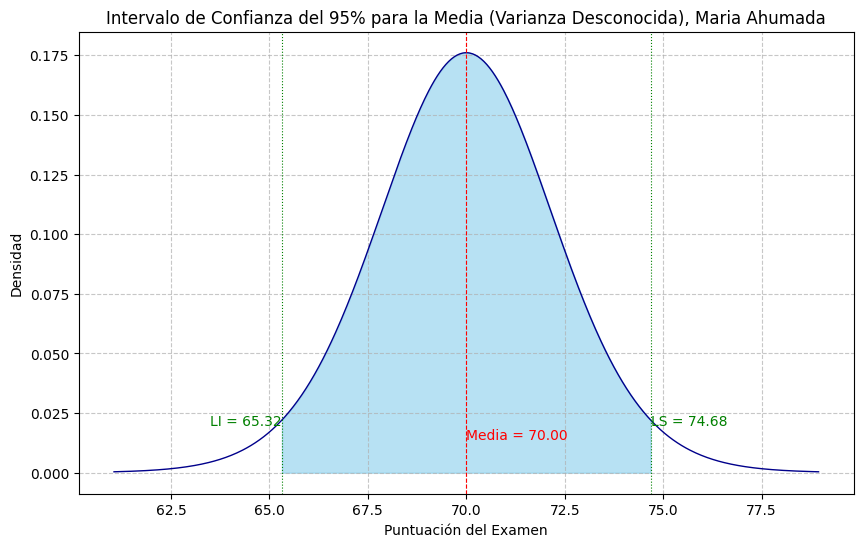

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# Parámetros del Problema 2 (Varianza Desconocida)
media_muestra_p2 = 70     # Media de la muestra
s_p2 = 10                 # Desviación estándar de la muestra
n_p2 = 20                 # Tamaño de la muestra
nivel_confianza_p2 = 0.95

# Cálculo del error estándar
error_estandar_p2 = s_p2 / np.sqrt(n_p2)

# Valor t crítico
t_critico_p2 = t.ppf(1 - (1 - nivel_confianza_p2) / 2, df = n_p2 - 1)

# Intervalo de confianza
limite_inferior_p2 = media_muestra_p2 - t_critico_p2 * error_estandar_p2
limite_superior_p2 = media_muestra_p2 + t_critico_p2 * error_estandar_p2

# Crear un rango de valores para la distribución t de Student
x_vals_p2 = np.linspace(media_muestra_p2 - 4 * error_estandar_p2, media_muestra_p2 + 4 * error_estandar_p2, 500)
y_vals_p2 = t.pdf(x_vals_p2, df=n_p2 - 1, loc=media_muestra_p2, scale=error_estandar_p2)

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(x_vals_p2, y_vals_p2, color='darkblue', linewidth=1)

# Sombrear el intervalo de confianza
x_fill_p2 = x_vals_p2[(x_vals_p2 >= limite_inferior_p2) & (x_vals_p2 <= limite_superior_p2)]
y_fill_p2 = y_vals_p2[(x_vals_p2 >= limite_inferior_p2) & (x_vals_p2 <= limite_superior_p2)]
plt.fill_between(x_fill_p2, 0, y_fill_p2, color='skyblue', alpha=0.6)

# Líneas verticales
plt.axvline(media_muestra_p2, color='red', linestyle='dashed', linewidth=0.8, label=f'Media = {media_muestra_p2:.2f}')
plt.axvline(limite_inferior_p2, color='green', linestyle='dotted', linewidth=0.8, label=f'LI = {limite_inferior_p2:.2f}')
plt.axvline(limite_superior_p2, color='green', linestyle='dotted', linewidth=0.8, label=f'LS = {limite_superior_p2:.2f}')

# Etiquetas y título
plt.title('Intervalo de Confianza del 95% para la Media (Varianza Desconocida), Maria Ahumada')
plt.xlabel('Puntuación del Examen')
plt.ylabel('Densidad')

# Anotaciones de texto
plt.text(limite_inferior_p2, plt.gca().get_ylim()[1] * 0.1, f'LI = {limite_inferior_p2:.2f}', horizontalalignment='right', verticalalignment='bottom', color='green')
plt.text(limite_superior_p2, plt.gca().get_ylim()[1] * 0.1, f'LS = {limite_superior_p2:.2f}', horizontalalignment='left', verticalalignment='bottom', color='green')
plt.text(media_muestra_p2, plt.gca().get_ylim()[1] * 0.1, f'Media = {media_muestra_p2:.2f}', horizontalalignment='left', verticalalignment='top', color='red')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## Problema 3: Intervalos de Confianza para Diferentes Niveles de Confianza
Usa los mismos datos del ejercicio 2 para calcular intervalos de confianza del 90%, 95% y 99%.




In [16]:
%%R
niveles_confianza <- c(0.90, 0.95, 0.99)

for (nivel in niveles_confianza) {
  t_critico <- qt(1 - (1 - nivel) / 2, df = n - 1)
  limite_inferior <- media_muestra - t_critico * error_estandar
  limite_superior <- media_muestra + t_critico * error_estandar
  cat("El intervalo de confianza del", nivel * 100, "% para la media es: [", limite_inferior, ",", limite_superior, "]\n")
}

El intervalo de confianza del 90 % para la media es: [ 66.13354 , 73.86646 ]
El intervalo de confianza del 95 % para la media es: [ 65.31986 , 74.68014 ]
El intervalo de confianza del 99 % para la media es: [ 63.60276 , 76.39724 ]


[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## Grafico ejercicio 3.


`height` was translated to `width`.


In addition: Warning message:
`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


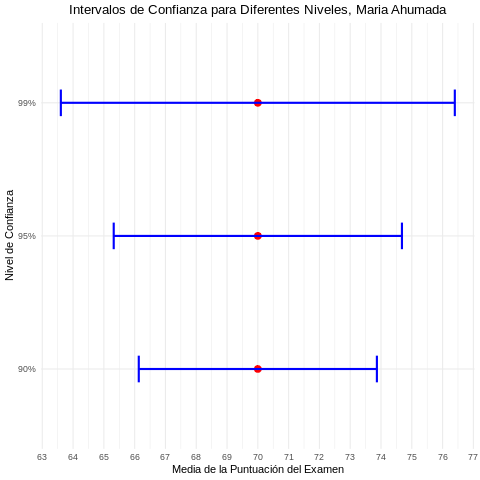

In [17]:
%%R
# Re-define los parámetros para el Problema 2 (Varianza Desconocida) para el gráfico
media_muestra_p2 <- 70     # Media de la muestra
s_p2 <- 10                 # Desviación estándar de la muestra
n_p2 <- 20                 # Tamaño de la muestra

# Cálculo del error estándar (del problema 2)
error_estandar_p2 <- s_p2 / sqrt(n_p2)

niveles_confianza <- c(0.90, 0.95, 0.99)
resultados_ci <- data.frame(
  Nivel = character(),
  Media = numeric(),
  Limite_Inferior = numeric(),
  Limite_Superior = numeric(),
  stringsAsFactors = FALSE
)

for (nivel in niveles_confianza) {
  t_critico <- qt(1 - (1 - nivel) / 2, df = n_p2 - 1)
  limite_inferior <- media_muestra_p2 - t_critico * error_estandar_p2
  limite_superior <- media_muestra_p2 + t_critico * error_estandar_p2
  resultados_ci <- rbind(resultados_ci, data.frame(
    Nivel = paste0(nivel * 100, "%"),
    Media = media_muestra_p2,
    Limite_Inferior = limite_inferior,
    Limite_Superior = limite_superior
  ))
}

# Asegúrate de que ggplot2 esté instalado y cargado
if (!requireNamespace("ggplot2", quietly = TRUE)) {
  install.packages("ggplot2")
}
library(ggplot2)

# Ordena los niveles para una mejor visualización
resultados_ci$Nivel <- factor(resultados_ci$Nivel, levels = c("90%", "95%", "99%"))

# Crea el gráfico
ggplot(resultados_ci, aes(y = Nivel, x = Media)) +
  geom_point(color = "red", size = 3) + # Grafica la media
  geom_errorbarh(aes(xmin = Limite_Inferior, xmax = Limite_Superior),
                 height = 0.2, color = "blue", size = 1) + # Grafica el CI como barras de error
  labs(title = "Intervalos de Confianza para Diferentes Niveles, Maria Ahumada",
       x = "Media de la Puntuación del Examen",
       y = "Nivel de Confianza") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5)) +
  scale_x_continuous(breaks = round(seq(min(resultados_ci$Limite_Inferior) - 1, max(resultados_ci$Limite_Superior) + 1, by = 1), 0))

[⬆️ Volver al inicio](#inicio)

<a name="T8"></a>
## Grafico ejercicio 3 con python.


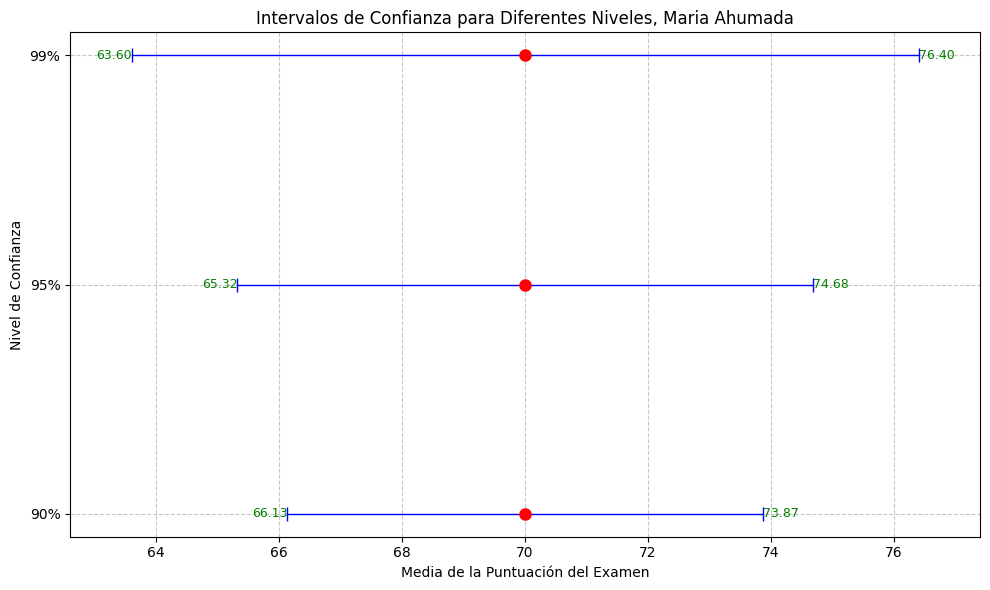

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
import pandas as pd

# Re-define los parámetros para el Problema 2 (Varianza Desconocida)
media_muestra_p2 = 70     # Media de la muestra
s_p2 = 10                 # Desviación estándar de la muestra
n_p2 = 20                 # Tamaño de la muestra

# Cálculo del error estándar
error_estandar_p2 = s_p2 / np.sqrt(n_p2)

niveles_confianza = [0.90, 0.95, 0.99]
ci_results = []

for nivel in niveles_confianza:
  # Valor t crítico
  t_critico = t.ppf(1 - (1 - nivel) / 2, df = n_p2 - 1)

  # Intervalo de confianza
  limite_inferior = media_muestra_p2 - t_critico * error_estandar_p2
  limite_superior = media_muestra_p2 + t_critico * error_estandar_p2
  ci_results.append({
      'Nivel': f'{int(nivel * 100)}%',
      'Media': media_muestra_p2,
      'Limite_Inferior': limite_inferior,
      'Limite_Superior': limite_superior
  })

df_ci = pd.DataFrame(ci_results)

# Ordenar los niveles para una mejor visualización
df_ci['Nivel'] = pd.Categorical(df_ci['Nivel'], categories=['90%', '95%', '99%'], ordered=True)
df_ci = df_ci.sort_values('Nivel')

# Crear el gráfico
plt.figure(figsize=(10, 6))

# Calcular el error (media - limite_inferior o limite_superior - media)
# Usaremos (limite_superior - limite_inferior) / 2 para xerr en errorbar
xerr_values = (df_ci['Limite_Superior'] - df_ci['Limite_Inferior']) / 2

plt.errorbar(x=df_ci['Media'],
             y=df_ci['Nivel'],
             xerr=xerr_values,
             fmt='o', # Formato para el punto de la media
             color='red', # Color del punto de la media
             ecolor='blue', # Color de la barra de error
             capsize=5, # Tamaño de los "caps" de la barra de error
             elinewidth=1, # Ancho de la línea de la barra de error
             ms=8, # Tamaño del marcador de la media
             label='Intervalo de Confianza')

# Etiquetas y título
plt.title('Intervalos de Confianza para Diferentes Niveles, Maria Ahumada')
plt.xlabel('Media de la Puntuación del Examen')
plt.ylabel('Nivel de Confianza')

# Añadir etiquetas de los límites para cada barra
for index, row in df_ci.iterrows():
    plt.text(row['Limite_Inferior'], row['Nivel'], f'{row["Limite_Inferior"]:.2f}',
             ha='right', va='center', color='green', fontsize=9)
    plt.text(row['Limite_Superior'], row['Nivel'], f'{row["Limite_Superior"]:.2f}',
             ha='left', va='center', color='green', fontsize=9)

plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(min(df_ci['Limite_Inferior']) - 1, max(df_ci['Limite_Superior']) + 1) # Ajustar límites del eje X
plt.tight_layout()
plt.show()

[⬆️ Volver al inicio](#inicio)



<a name="T9"></a>
## Problema 4: Intervalos de Confianza con Datos Simulados
Genera una muestra aleatoria de datos y calcula el intervalo de confianza para la media.


In [21]:
%%R
set.seed(123)  # Fijar la semilla para reproducibilidad
muestra <- rnorm(50, mean = 65, sd = 12)

media_muestra <- mean(muestra)
s <- sd(muestra)
n <- length(muestra)
nivel_confianza <- 0.95

# Cálculo del error estándar y valor t crítico
error_estandar <- s / sqrt(n)
t_critico <- qt(1 - (1 - nivel_confianza) / 2, df = n - 1)

# Intervalo de confianza
limite_inferior <- media_muestra - t_critico * error_estandar
limite_superior <- media_muestra + t_critico * error_estandar

cat("El intervalo de confianza del 95% para la media de la muestra simulada es: [", limite_inferior, ",", limite_superior, "]\n")

El intervalo de confianza del 95% para la media de la muestra simulada es: [ 62.25529 , 68.57039 ]


[⬆️ Volver al inicio](#inicio)

<a name="T10"></a>
## Grafico ejercicio 4.




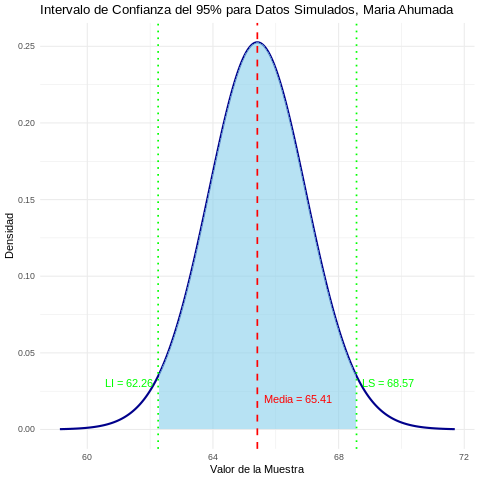

In [22]:
%%R
# Asegúrate de que ggplot2 esté instalado y cargado
if (!requireNamespace("ggplot2", quietly = TRUE)) {
  install.packages("ggplot2")
}
library(ggplot2)

# Reutilizar los parámetros calculados en el Problema 4
# media_muestra, s, n, nivel_confianza, error_estandar, t_critico, limite_inferior, limite_superior
# Estos ya están definidos y calculados en la celda anterior (v-NnqsuVIrfm)

# Crear un rango de valores para la distribución t de Student
# Para una muestra simulada, la distribución subyacente que usamos para el CI es la t-student
x_vals_sim <- seq(media_muestra - 4 * error_estandar, media_muestra + 4 * error_estandar, length.out = 500)
y_vals_sim <- dt((x_vals_sim - media_muestra) / error_estandar, df = n - 1) / error_estandar

# Crear un dataframe para ggplot
df_plot_sim <- data.frame(x = x_vals_sim, y = y_vals_sim)

# Crear el gráfico
ggplot(df_plot_sim, aes(x = x, y = y)) +
  geom_line(color = "darkblue", size = 1) +
  geom_ribbon(data = subset(df_plot_sim, x >= limite_inferior & x <= limite_superior),
              aes(ymin = 0, ymax = y), fill = "skyblue", alpha = 0.6) +
  geom_vline(xintercept = media_muestra, linetype = "dashed", color = "red", size = 0.8) +
  geom_vline(xintercept = limite_inferior, linetype = "dotted", color = "green", size = 0.8) +
  geom_vline(xintercept = limite_superior, linetype = "dotted", color = "green", size = 0.8) +
  labs(title = "Intervalo de Confianza del 95% para Datos Simulados, Maria Ahumada",
       x = "Valor de la Muestra",
       y = "Densidad") +
  annotate("text", x = limite_inferior, y = max(y_vals_sim) * 0.1, label = paste0("LI = ", round(limite_inferior, 2)), hjust = 1.1, vjust = -0.5, color = "green") +
  annotate("text", x = limite_superior, y = max(y_vals_sim) * 0.1, label = paste0("LS = ", round(limite_superior, 2)), hjust = -0.1, vjust = -0.5, color = "green") +
  annotate("text", x = media_muestra, y = max(y_vals_sim) * 0.1, label = paste0("Media = ", round(media_muestra, 2)), hjust = -0.1, vjust = 1.5, color = "red") +
  theme_minimal()


[⬆️ Volver al inicio](#inicio)

<a name="T11"></a>
## Grafico ejercicio 4 con python.


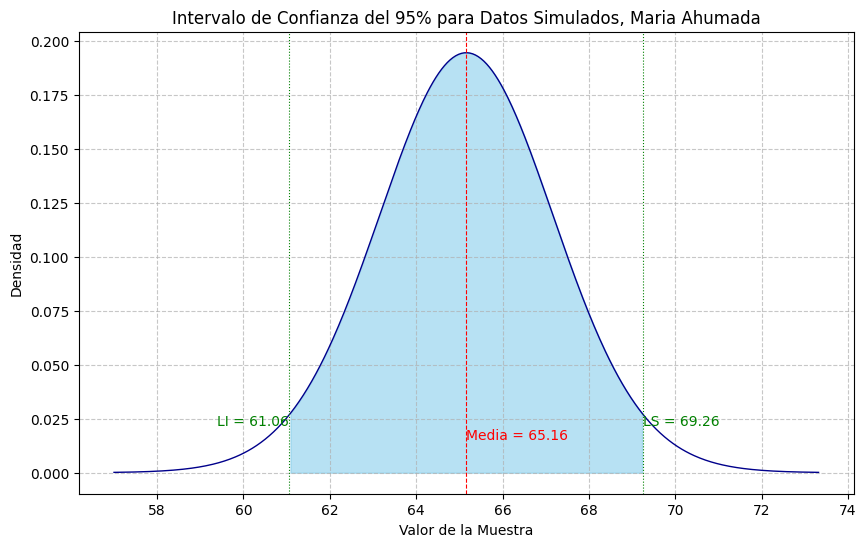

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# Re-simular los datos en Python para asegurar la disponibilidad de las variables
np.random.seed(123)  # Fijar la semilla para reproducibilidad, igual que en R
muestra_py = np.random.normal(loc=65, scale=12, size=50)

media_muestra_py = np.mean(muestra_py)
s_py = np.std(muestra_py, ddof=1) # ddof=1 para la desviación estándar muestral no sesgada
n_py = len(muestra_py)
nivel_confianza_py = 0.95 # Definir explícitamente el nivel de confianza

# Cálculo del error estándar
error_estandar_py = s_py / np.sqrt(n_py)

# Valor t crítico
t_critico_py = t.ppf(1 - (1 - nivel_confianza_py) / 2, df=n_py - 1)

# Intervalo de confianza
limite_inferior_py = media_muestra_py - t_critico_py * error_estandar_py
limite_superior_py = media_muestra_py + t_critico_py * error_estandar_py

# Crear un rango de valores para la distribución t de Student
x_vals_sim_py = np.linspace(media_muestra_py - 4 * error_estandar_py, media_muestra_py + 4 * error_estandar_py, 500)
y_vals_sim_py = t.pdf(x_vals_sim_py, df=n_py - 1, loc=media_muestra_py, scale=error_estandar_py)

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(x_vals_sim_py, y_vals_sim_py, color='darkblue', linewidth=1)

# Sombrear el intervalo de confianza
x_fill_sim_py = x_vals_sim_py[(x_vals_sim_py >= limite_inferior_py) & (x_vals_sim_py <= limite_superior_py)]
y_fill_sim_py = y_vals_sim_py[(x_vals_sim_py >= limite_inferior_py) & (x_vals_sim_py <= limite_superior_py)]
plt.fill_between(x_fill_sim_py, 0, y_fill_sim_py, color='skyblue', alpha=0.6)

# Líneas verticales
plt.axvline(media_muestra_py, color='red', linestyle='dashed', linewidth=0.8, label=f'Media = {media_muestra_py:.2f}')
plt.axvline(limite_inferior_py, color='green', linestyle='dotted', linewidth=0.8, label=f'LI = {limite_inferior_py:.2f}')
plt.axvline(limite_superior_py, color='green', linestyle='dotted', linewidth=0.8, label=f'LS = {limite_superior_py:.2f}')

# Etiquetas y título
plt.title('Intervalo de Confianza del 95% para Datos Simulados, Maria Ahumada')
plt.xlabel('Valor de la Muestra')
plt.ylabel('Densidad')

# Anotaciones de texto
plt.text(limite_inferior_py, plt.gca().get_ylim()[1] * 0.1, f'LI = {limite_inferior_py:.2f}', horizontalalignment='right', verticalalignment='bottom', color='green')
plt.text(limite_superior_py, plt.gca().get_ylim()[1] * 0.1, f'LS = {limite_superior_py:.2f}', horizontalalignment='left', verticalalignment='bottom', color='green')
plt.text(media_muestra_py, plt.gca().get_ylim()[1] * 0.1, f'Media = {media_muestra_py:.2f}', horizontalalignment='left', verticalalignment='top', color='red')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

[⬆️ Volver al inicio](#inicio)

<a name="T12"></a>
## **12. **


[⬆️ Volver al inicio](#inicio)

<a name="T13"></a>
## **13. **


[⬆️ Volver al inicio](#inicio)

<a name="T14"></a>
## **14. **


[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **15. **




[⬆️ Volver al inicio](#inicio)

<a name="T16"></a>
## **16. **


[⬆️ Volver al inicio](#inicio)

<a name="T17"></a>
## **17. **




[⬆️ Volver al inicio](#inicio)

<a name="T18"></a>
## **18. **


[⬆️ Volver al inicio](#inicio)

<a name="T19"></a>
## **19. **


[⬆️ Volver al inicio](#inicio)

<a name="T20"></a>
## **20. **




[⬆️ Volver al inicio](#inicio)

<a name="T21"></a>
## **21. **


[⬆️ Volver al inicio](#inicio)

<a name="T22"></a>
## **22. **


[⬆️ Volver al inicio](#inicio)

<a name="T23"></a>
## **23. **


[⬆️ Volver al inicio](#inicio)

<a name="T24"></a>
## **24. **


[⬆️ Volver al inicio](#inicio)

<a name="T25"></a>
## **25. **




[⬆️ Volver al inicio](#inicio)

<a name="T26"></a>
## **26. **


[⬆️ Volver al inicio](#inicio)

<a name="T27"></a>
## **27. **




[⬆️ Volver al inicio](#inicio)

<a name="T28"></a>
## **28. **


[⬆️ Volver al inicio](#inicio)

<a name="T29"></a>
## **29. **


[⬆️ Volver al inicio](#inicio)

<a name="T30"></a>
## **30. **




[⬆️ Volver al inicio](#inicio)


## **ULTIMO**
[⬆️ Volver al ULTIMO](#ULTIMO)


<a name="ULTIMO"></a>

[⬆️ Volver al inicio](#inicio)

ULTIMO